# Insights on Multi-Family Sales in Chicago
### 10 Questions for a Chicago Real-Estate Trivia Night - Multi-Family Companion

The two-to-four-flat market - Chicago's classic small apartment buildings. MF lives
in the **same parquet as single-family** (`meta_modeling_group == 'MF'`) with full
characteristics, so this companion gets the **full analysis, $/sqft included** - just
`K.MF` instead of `K.SF`. Compute in `analysis/sales_descriptives.py`, renderers in
`viz/charts.py` (**entity = orange, individual = blue** wherever the two are split).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import constants as K
from chicago_housing.data import wrangling
from chicago_housing.analysis import sales_descriptives as sd
from chicago_housing.viz import charts, maps

pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

### Setup - the clean multi-family sample

Chicago + MF + 2022-25, drop multi-card / prorated and non-arm's-length. The one-call
helper reads the `K.MF` config (same parquet as SF, `MF` modeling group, 3-side N/W/S
map). The Loop's ~2 MF sales fall outside the 3-side scheme and are dropped so every
tally reconciles.

In [2]:
enriched = wrangling.load_sales_sample(K.MF)
print("clean multi-family sample:", enriched.shape)

scope_filter [mf]:  405,195 ->   19,223 rows
apply_drop_policy: 19,223 -> 17,662
  statutory (PTAX/family): 981
  below $10,000 floor:    0
  entity + price-corrob.:  785
dropped 6 unmapped / no-geo rows
add_region [mf]: {'North': 5899, 'West': 4845, 'South': 6912}
clean multi-family sample: (17656, 29)


## First, the lay of the land - the two-flat belt

Multi-family flips single-family's geography toward the middle: sales split **South
39% / North 33% / West 28%** - far more even than single-family (54/37/9). The
two-to-four-flat is a **West- and South-Side** staple in a way the single-family
market never was. Same three sides as the SF piece (K.MF reuses the N/W/S map).

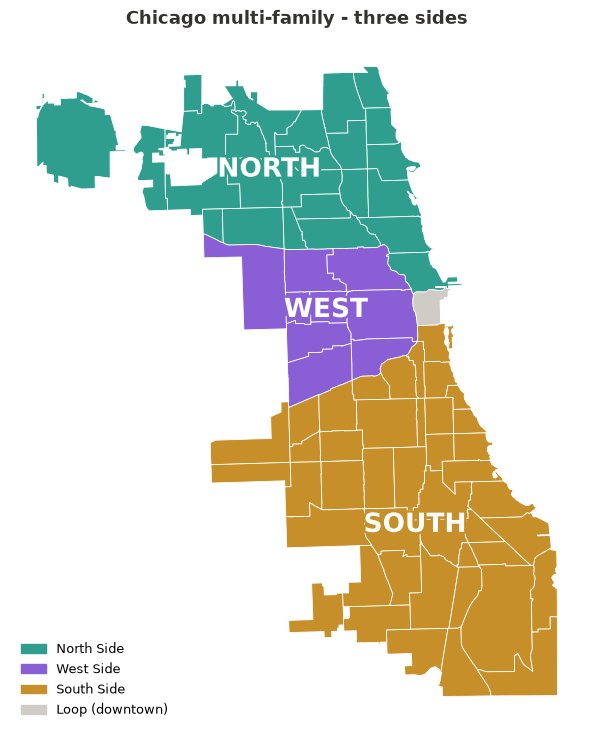

In [3]:
maps.region_map_static(K.MF, title="Chicago multi-family - three sides")
plt.show()

maps.region_map(enriched, K.MF, sales_label="MF sales 22-25:").save("mf_region_map.html")

---
## Q1 - How many multi-family buildings sold in Chicago in 2025?

**About 4,100 two-to-four-flats** - and like single-family, the drop was one cliff:
-20% in 2023, then flat (+0.4%, -1.9%). MF tracks the SF market's shape almost exactly.
The steepest regional decline was the North Side (-28%); the **West Side held up best
(-12%)** - fitting for the city's two-flat heartland.

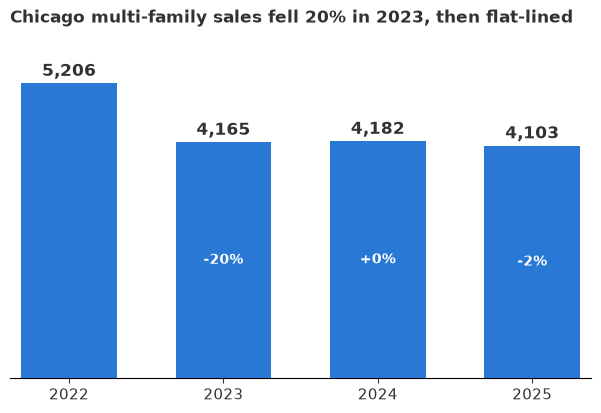

In [4]:
charts.plot_total_sales_by_year(
    sd.sales_by_year(enriched),
    title="Chicago multi-family sales fell 20% in 2023, then flat-lined")
plt.show()

In [5]:
nb_vol = sd.sales_by_neighborhood_wide(enriched)
_tot = nb_vol[['2022', '2023', '2024', '2025']].sum()
print(f"CITYWIDE  2022={_tot['2022']:,}  2023={_tot['2023']:,}  "
      f"2024={_tot['2024']:,}  2025={_tot['2025']:,}   ({len(nb_vol)} neighborhoods)")
nb_vol

CITYWIDE  2022=5,206  2023=4,165  2024=4,182  2025=4,103   (76 neighborhoods)


meta_year,loc_chicago_community_area_name,region,2022,2023,2024,2025,delta_pct
0,WEST TOWN,West,256,209,202,245,-4.300
1,AUSTIN,West,262,238,266,224,-14.500
2,LOGAN SQUARE,North,240,180,191,185,-22.900
3,NORTH LAWNDALE,West,183,152,173,174,-4.900
4,HUMBOLDT PARK,West,168,152,158,160,-4.800
5,ENGLEWOOD,South,142,138,143,134,-5.600
6,GREATER GRAND CROSSING,South,156,119,109,130,-16.700
7,PORTAGE PARK,North,134,94,120,121,-9.700
8,LAKE VIEW,North,150,138,121,113,-24.700
9,NEW CITY,South,158,144,110,111,-29.700


---
## Q2 - Where do two-flats sell?

**The West Side is the two-flat belt.** Unlike single-family (South-dominated) or condos
(downtown), MF sales spread **South 39% / North 33% / West 28%**, and the busiest
neighborhoods are overwhelmingly West Side: **West Town (245), Austin (224), North
Lawndale, Humboldt Park** - the classic worker's two-flat corridors - with Logan Square
and Englewood close behind.

In [6]:
sd.sales_by_neighborhood_wide(enriched, group_by='region')

meta_year,region,2022,2023,2024,2025,delta_pct
0,South,2034,1667,1622,1589,-21.900
1,North,1826,1354,1395,1324,-27.500
2,West,1346,1144,1165,1190,-11.600


---
## Q3 - What does a two-flat sell for, and did prices rise?

**Prices jumped +16% - the biggest gain of any market** ($395k -> $460k, more than
single-family's +7% or condos' +12%). And a two-flat is no starter home: the median in
**Lincoln Park is $1.5M**, Lake View $1.25M, Uptown $1.16M. The priciest MF neighborhoods
are the North/West lakefront; the busiest (West Side) are far cheaper.

In [7]:
price = sd.median_price_two_year(enriched, '2022', '2025').join(
    enriched[[K.REPORT_GEO, K.REGION_COL]].drop_duplicates().set_index(K.REPORT_GEO))
_cw = enriched.groupby(enriched['meta_year'].astype('string'))[K.TARGET_RAW].median()
print(f"CITYWIDE median  2022 ${_cw['2022']:,.0f}  ->  2025 ${_cw['2025']:,.0f}"
      f"  ({(_cw['2025']/_cw['2022'] - 1) * 100:+.1f}%)")
price.sort_values('med_2025', ascending=False)

CITYWIDE median  2022 $395,450  ->  2025 $460,000  (+16.3%)


,med_2022,n_2022,med_2025,n_2025,delta_pct,region
loc_chicago_community_area_name,,,,,,
NEAR SOUTH SIDE,NaN,0,"5,100,000.000",1,NaN,South
NEAR NORTH SIDE,"1,360,000.000",6,"1,812,500.000",4,33.300,North
LINCOLN PARK,"1,250,000.000",102,"1,499,000.000",95,19.900,North
LAKE VIEW,"947,450.000",150,"1,250,000.000",113,31.900,North
UPTOWN,"928,250.000",40,"1,162,500.000",24,25.200,North
WEST TOWN,"792,500.000",256,"949,000.000",245,19.700,West
OHARE,"600,000.000",15,"899,000.000",7,49.800,North
NORTH CENTER,"775,000.000",124,"890,000.000",62,14.800,North
KENWOOD,"575,000.000",2,"887,500.000",2,54.300,South


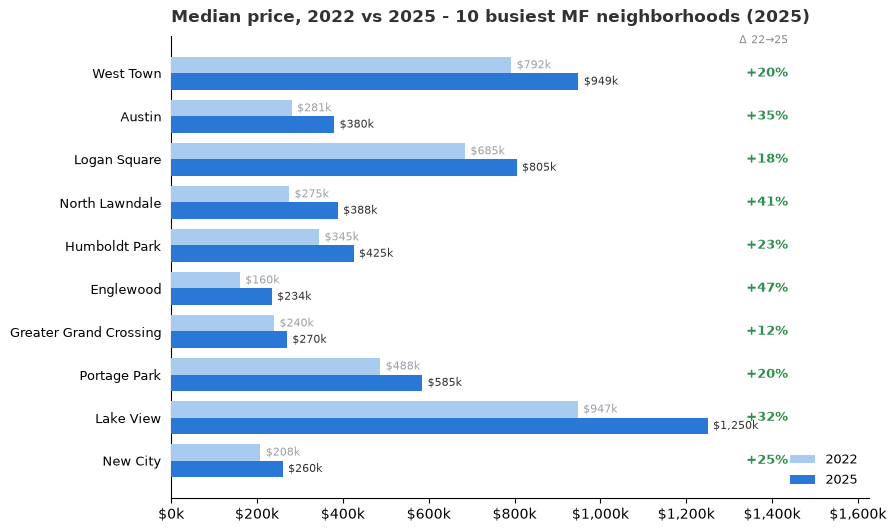

In [8]:
top10_vol = sd.top_neighborhoods(
    enriched[enriched['meta_year'].astype('string') == '2025'], 10)[K.REPORT_GEO].tolist()
charts.plot_median_price_2yr(
    price, top10_vol, "Median price, 2022 vs 2025 - 10 busiest MF neighborhoods (2025)")
plt.show()

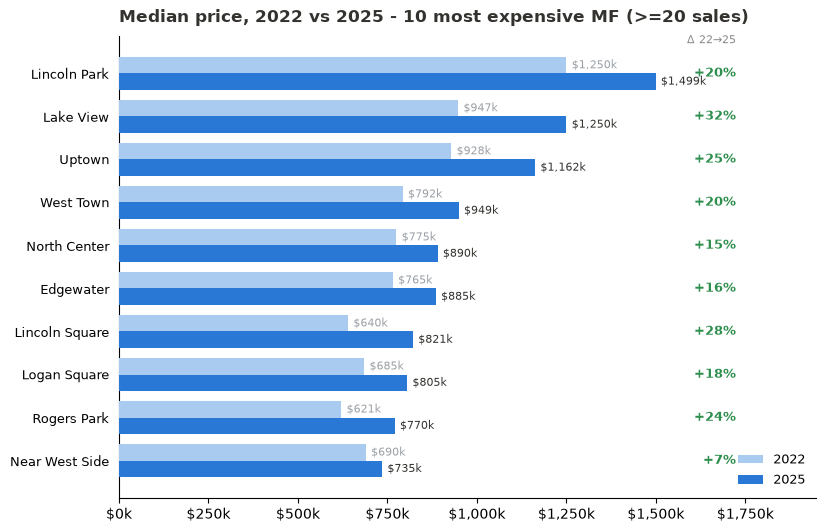

In [9]:
top10_exp = sd.neighborhoods_by_year_price(
    enriched, year='2025', min_sales=20).head(10).index.tolist()
charts.plot_median_price_2yr(
    price, top10_exp, "Median price, 2022 vs 2025 - 10 most expensive MF (>=20 sales)")
plt.show()

---
## Q4 - What's the most expensive multi-family building sold?

**A $5.8M, 18-bedroom vintage building at 2244 N Kenmore in Lincoln Park** (1926, 8,541
sqft). MF trophies are big early-century apartment buildings - $5.1M on S Michigan (Near
South), $5M in Lake View, a **19,620-sqft** building in West Town. And the biggest building
isn't the priciest per foot: 2244 N Kenmore went for $679/sqft, under several smaller
trophies.

In [10]:
from IPython.display import display
display(sd.top_sales(enriched, '2022', 5).style.hide(axis='index')
        .format({'price': '${:,.0f}', '$/sqft': '${:,.0f}'}).set_caption('Top 5 MF - 2022'))
display(sd.top_sales(enriched, '2025', 5).style.hide(axis='index')
        .format({'price': '${:,.0f}', '$/sqft': '${:,.0f}'}).set_caption('Top 5 MF - 2025'))

year,price,$/sqft,sqft,beds,baths,year_built,neighborhood,address,side
2022,"$3,250,000",$258,12621,2,2,1920,Lake View,1134 W BELMONT AVE,North
2022,"$3,018,000",$684,4411,4,4,1901,Near North Side,79 E ELM ST,North
2022,"$2,975,000",$790,3765,8,7,2022,Lincoln Park,2051 N CLIFTON AVE,North
2022,"$2,935,000",$843,3480,7,4,2020,Lincoln Park,2464 N BURLING ST UNIT 2,North
2022,"$2,765,000",$334,8271,14,8,1913,Logan Square,2852 W SHAKESPEARE AVE,North


year,price,$/sqft,sqft,beds,baths,year_built,neighborhood,address,side
2025,"$5,800,000",$679,8541,18,6,1926,Lincoln Park,2244 N KENMORE AVE,North
2025,"$5,100,000",$453,11270,4,6,1922,Near South Side,2335 S MICHIGAN AVE,South
2025,"$5,000,000",$513,9743,8,4,1888,Lake View,3358 N SOUTHPORT AVE,North
2025,"$4,850,000",$247,19620,7,3,1916,West Town,1745 W POTOMAC AVE,West
2025,"$3,695,000",$683,5412,11,9,1893,Lake View,3615 N WILTON AVE,North


In [11]:
combined = (pd.concat([sd.top_sales(enriched, '2022', 5), sd.top_sales(enriched, '2025', 5)])
              .sort_values('price', ascending=False).reset_index(drop=True))
combined.style.hide(axis='index').format({'price': '${:,.0f}', '$/sqft': '${:,.0f}'}) \
    .set_caption('Most expensive MF sales, 2022 & 2025 combined')

year,price,$/sqft,sqft,beds,baths,year_built,neighborhood,address,side
2025,"$5,800,000",$679,8541,18,6,1926,Lincoln Park,2244 N KENMORE AVE,North
2025,"$5,100,000",$453,11270,4,6,1922,Near South Side,2335 S MICHIGAN AVE,South
2025,"$5,000,000",$513,9743,8,4,1888,Lake View,3358 N SOUTHPORT AVE,North
2025,"$4,850,000",$247,19620,7,3,1916,West Town,1745 W POTOMAC AVE,West
2025,"$3,695,000",$683,5412,11,9,1893,Lake View,3615 N WILTON AVE,North
2022,"$3,250,000",$258,12621,2,2,1920,Lake View,1134 W BELMONT AVE,North
2022,"$3,018,000",$684,4411,4,4,1901,Near North Side,79 E ELM ST,North
2022,"$2,975,000",$790,3765,8,7,2022,Lincoln Park,2051 N CLIFTON AVE,North
2022,"$2,935,000",$843,3480,7,4,2020,Lincoln Park,2464 N BURLING ST UNIT 2,North
2022,"$2,765,000",$334,8271,14,8,1913,Logan Square,2852 W SHAKESPEARE AVE,North


---
## Q5 - Do entity buyers pay less for two-flats?

**It's about where - and MF adds a twist.** Entities are a bigger force here (**~30% of
buyers**, vs ~16% for single-family):
- **South Side:** deep discount - entities pay **-43% on price and -51% per square foot**.
- **North & West:** entities pay *more in total* (+26% / +11%) because they buy **bigger
  buildings**, but about the same or less per foot (-2% / -19%).
- **Lake View** is the lone premium - entities pay **+6% per foot** (n=58), the two-flat
  echo of single-family's Lincoln Park story.

$/sqft is the fair lens (MF has it, unlike condos): the South-Side discount is real, not
just building size.

,group,year,n_ent,n_ind,ent_share,price_ent,price_ind,ppsf_ent,ppsf_ind,price_diff_pct,ppsf_diff_pct,reliable
0,North,2022,446,1380,24.000,"732,500.000","570,000.000",223.000,221.000,28.000,1.000,True
1,West,2022,335,1011,25.000,"360,000.000","356,200.000",105.000,143.000,1.000,-27.000,True
2,South,2022,552,1482,27.000,"181,250.000","287,250.000",57.000,114.000,-37.000,-50.000,True
3,North,2025,415,909,31.000,"855,000.000","679,000.000",257.000,264.000,26.000,-2.000,True
4,West,2025,369,821,31.000,"490,000.000","440,000.000",140.000,173.000,11.000,-19.000,True
5,South,2025,461,1128,29.000,"194,000.000","342,450.000",67.000,136.000,-43.000,-51.000,True


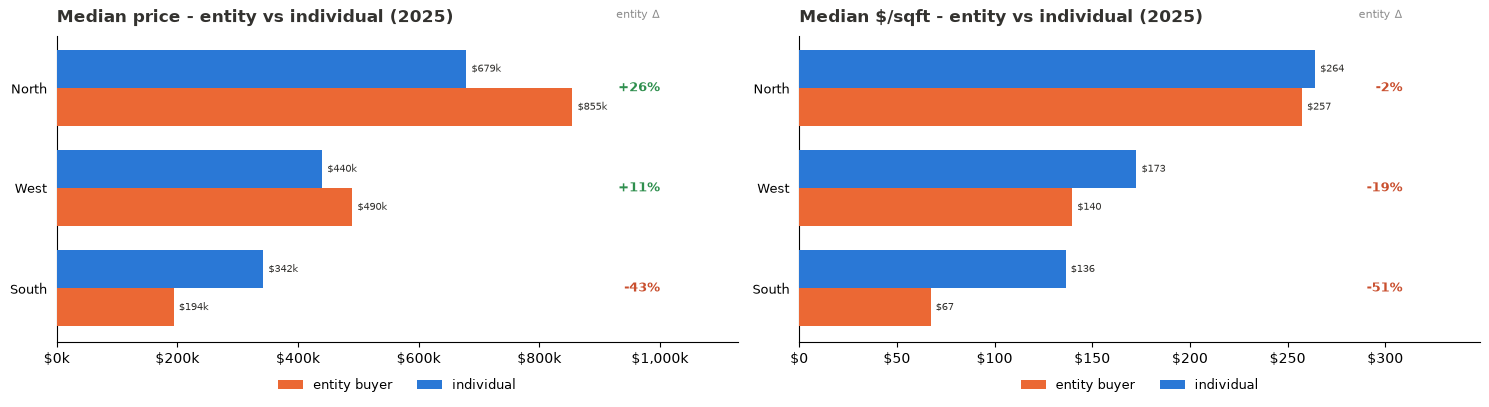

In [12]:
from IPython.display import display
side = sd.entity_individual_split(enriched, K.REGION_COL, years=('2022', '2025'))
display(side.round(0))

side25 = side[side['year'] == '2025']
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
charts.plot_entity_metric_by_group(side25, K.MF.region_order, 'price',
    "Median price - entity vs individual (2025)", money='k', ax=axes[0])
charts.plot_entity_metric_by_group(side25, K.MF.region_order, 'ppsf',
    "Median $/sqft - entity vs individual (2025)", money='plain', ax=axes[1])
fig.tight_layout(); plt.show()

,group,year,n_ent,n_ind,ent_share,price_ent,price_ind,ppsf_ent,ppsf_ind,price_diff_pct,ppsf_diff_pct,reliable
0,AUSTIN,2025,47,177,21.000,"240,000.000","397,000.000",85.000,158.000,-40.000,-46.000,True
1,ENGLEWOOD,2025,44,90,33.000,"101,000.000","316,450.000",38.000,130.000,-68.000,-71.000,True
2,GREATER GRAND CROSSING,2025,38,92,29.000,"153,500.000","299,500.000",54.000,121.000,-49.000,-56.000,True
3,HUMBOLDT PARK,2025,44,116,28.000,"340,000.000","448,250.000",113.000,183.000,-24.000,-39.000,True
4,LAKE VIEW,2025,58,55,51.000,"1,250,000.000","1,253,000.000",387.000,366.000,-0.000,6.000,True
5,LOGAN SQUARE,2025,57,128,31.000,"725,000.000","817,500.000",260.000,325.000,-11.000,-20.000,True
6,NEW CITY,2025,27,84,24.000,"165,000.000","282,500.000",72.000,127.000,-42.000,-43.000,True
7,NORTH LAWNDALE,2025,47,127,27.000,"310,000.000","400,000.000",85.000,118.000,-22.000,-28.000,True
8,PORTAGE PARK,2025,29,92,24.000,"620,000.000","581,000.000",196.000,250.000,7.000,-22.000,True
9,WEST TOWN,2025,117,128,48.000,"970,000.000","927,500.000",288.000,296.000,5.000,-3.000,True


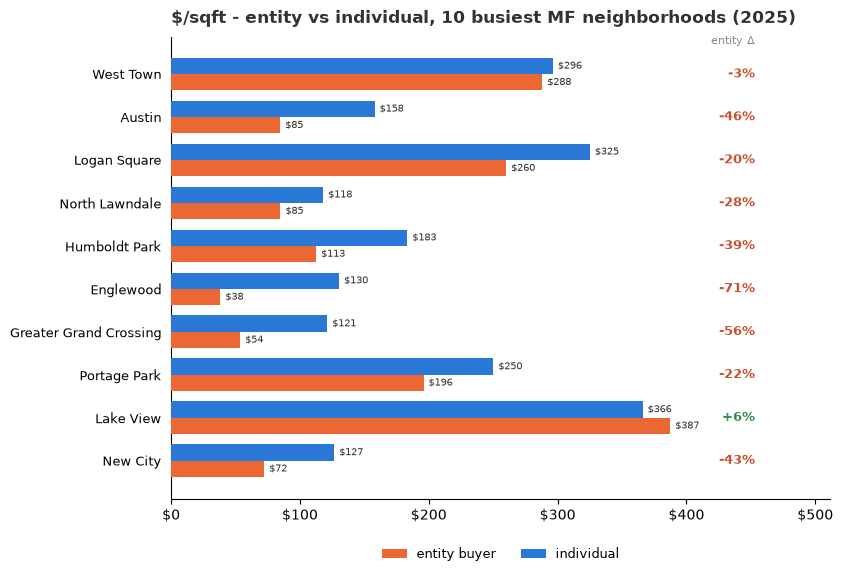

In [13]:
vol10 = sd.top_neighborhoods(
    enriched[enriched['meta_year'].astype('string') == '2025'], 10)[K.REPORT_GEO].tolist()
vol_split = sd.entity_individual_split(
    enriched[enriched[K.REPORT_GEO].isin(vol10)], K.REPORT_GEO, years=('2025',))
display(vol_split.round(0))
charts.plot_entity_metric_by_group(
    vol_split, vol10, 'ppsf',
    "$/sqft - entity vs individual, 10 busiest MF neighborhoods (2025)", money='plain')
plt.show()

,group,year,n_ent,n_ind,ent_share,price_ent,price_ind,ppsf_ent,ppsf_ind,price_diff_pct,ppsf_diff_pct,reliable
0,EDGEWATER,2025,11,27,29.000,"801,275.000","905,000.000",266.000,347.000,-12.000,-23.000,True
1,LAKE VIEW,2025,58,55,51.000,"1,250,000.000","1,253,000.000",387.000,366.000,-0.000,6.000,True
2,LINCOLN PARK,2025,52,43,55.000,"1,567,500.000","1,450,000.000",429.000,442.000,8.000,-3.000,True
3,LINCOLN SQUARE,2025,21,35,38.000,"760,000.000","837,600.000",272.000,300.000,-9.000,-9.000,True
4,LOGAN SQUARE,2025,57,128,31.000,"725,000.000","817,500.000",260.000,325.000,-11.000,-20.000,True
5,NEAR WEST SIDE,2025,21,26,45.000,"775,000.000","708,500.000",214.000,268.000,9.000,-20.000,True
6,NORTH CENTER,2025,32,30,52.000,"861,250.000","902,250.000",317.000,373.000,-4.000,-15.000,True
7,ROGERS PARK,2025,11,21,34.000,"900,000.000","758,000.000",178.000,221.000,19.000,-19.000,True
8,UPTOWN,2025,15,9,62.000,"1,230,000.000","985,000.000",243.000,314.000,25.000,-23.000,True
9,WEST TOWN,2025,117,128,48.000,"970,000.000","927,500.000",288.000,296.000,5.000,-3.000,True


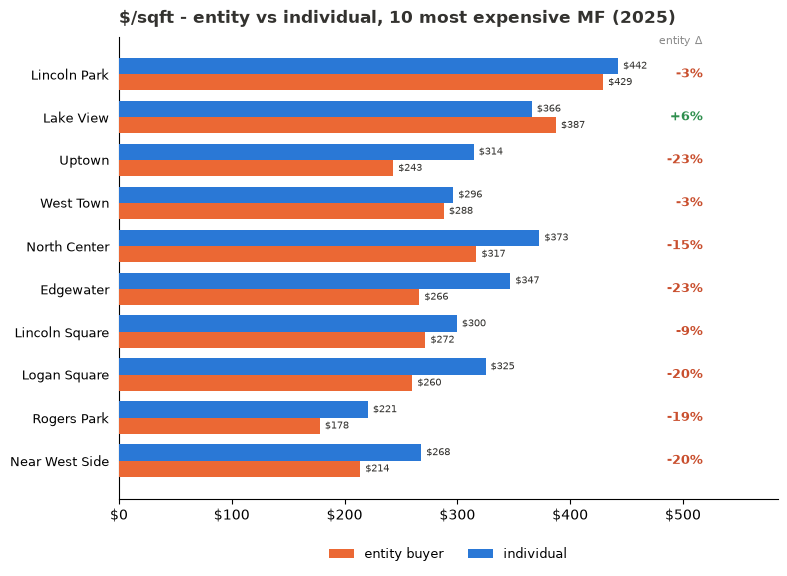

In [14]:
exp10 = sd.neighborhoods_by_year_price(
    enriched, year='2025', min_sales=20).head(10).index.tolist()
exp_split = sd.entity_individual_split(
    enriched[enriched[K.REPORT_GEO].isin(exp10)], K.REPORT_GEO, years=('2025',))
display(exp_split.round(0))
charts.plot_entity_metric_by_group(
    exp_split, exp10, 'ppsf',
    "$/sqft - entity vs individual, 10 most expensive MF (2025)", money='plain')
plt.show()

---
## Q6 - Who are the two-flat investors?

**Grandview again** - Chicago's most active buyer across every property type - tops MF too
(31 buildings, Auburn Gresham). Behind it, familiar South-Side names (Bricksave, Connolly
Capital) plus MF-specific players (ETS, ABI Invest, Vig Estates), and the **Chicago Title
Land Trust** privacy vehicle reappears up North (Lake View, $820k median). Still a long
tail: **4,823 entity buys, 3,730 distinct buyers, 3,181 bought exactly one.**

In [15]:
from IPython.display import display
_names = sd.normalize_entity_name(enriched.loc[enriched['entity_buyer'], K.BUYER_NAME])
print(f"entity buys: {int(enriched['entity_buyer'].sum()):,}   distinct buyers: "
      f"{_names.nunique():,}   bought exactly once: {int((_names.value_counts() == 1).sum()):,}")
lb = sd.entity_buyer_leaderboard(enriched, n=15)
display(lb.style.hide(axis='index')
        .format({'median_price': '${:,.0f}', 'total_spent': '${:,.0f}'}))

entity buys: 4,823   distinct buyers: 3,730   bought exactly once: 3,181


entity,homes,median_price,total_spent,top_side,home_turf
GRANDVIEW,31,"$165,000","$6,049,500",South,AUBURN GRESHAM (3/31)
ETS,18,"$495,000","$10,115,000",South,AUBURN GRESHAM (9/18)
BRICKSAVE,17,"$110,000","$2,049,000",South,GREATER GRAND CROSSING (4/17)
ABI INVEST IL,14,"$627,500","$8,575,000",North,LOGAN SQUARE (5/14)
CHICAGO TITLE LAND TRUST COMPANY,14,"$819,500","$14,372,288",North,LAKE VIEW (2/14)
VIG ESTATES,13,"$70,000","$982,200",South,ENGLEWOOD (5/13)
CONNOLLY CAPITAL,12,"$140,000","$2,030,735",South,AUBURN GRESHAM (7/12)
TULE RIVER HOMEBUYER EARNED EQUITY AGENCY,11,"$410,000","$4,498,200",West,HUMBOLDT PARK (3/11)
CONSTRUCTION REHAB SERVICES,10,"$100,000","$1,545,000",South,WEST ENGLEWOOD (3/10)
EZMB,10,"$785,000","$8,686,000",North,LAKE VIEW (6/10)


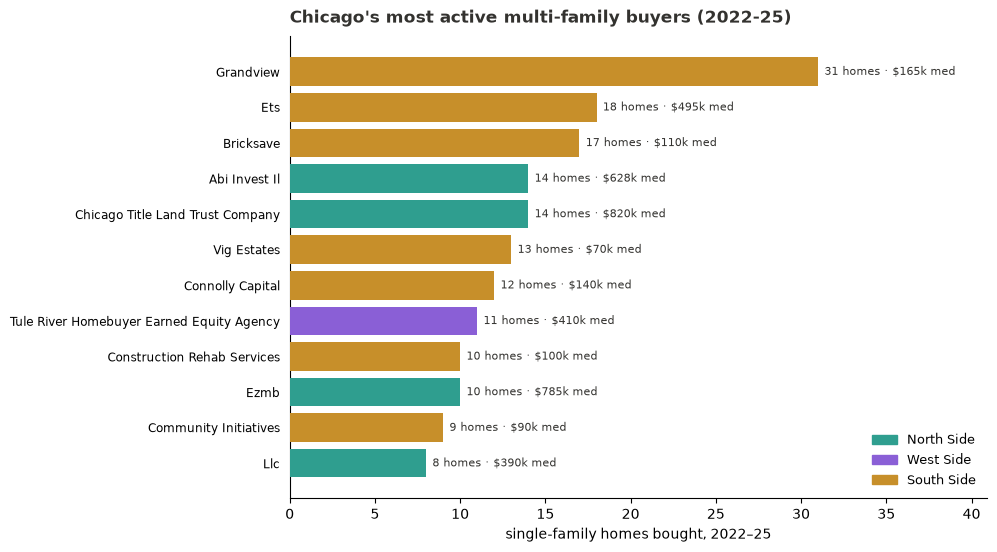

In [16]:
charts.plot_entity_buyer_leaderboard(
    lb, n=12, title="Chicago's most active multi-family buyers (2022-25)")
plt.show()

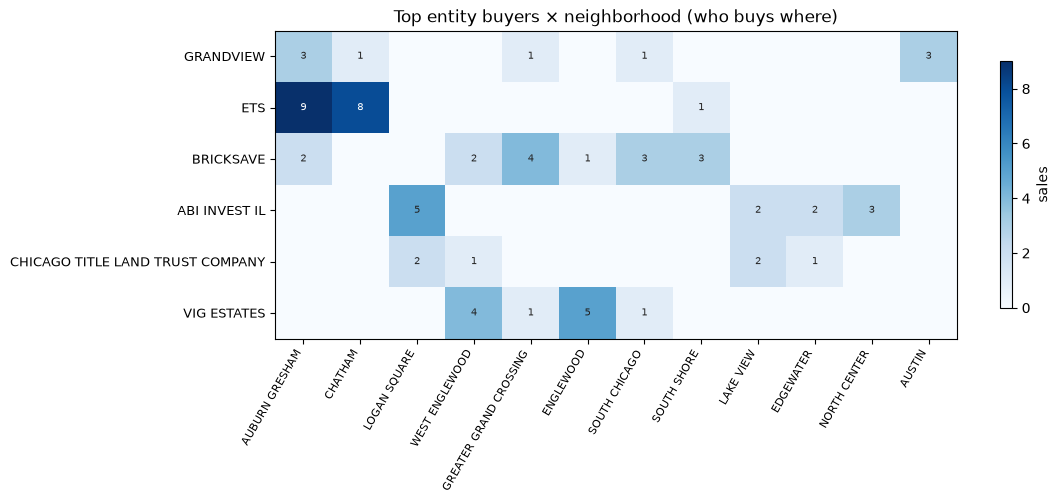

In [17]:
mat = sd.entity_neighborhood_matrix(enriched, side='buyer',
                                    top_entities_n=6, top_neighborhoods_n=12)
charts.plot_entity_neighborhood_heatmap(mat)
plt.show()

---
## Q7 - How many two-flats get flipped, and where?

**788 flips, 62% entity-bought** - between single-family (73%) and condos (41%). And the
geography is the most even of the three markets: flip share **West 4.8% / South 4.7% /
North 3.9%**. By share the standout is a surprise - **Lincoln Park (12.9%)**, where pricey
two-flats get renovated and resold - alongside the usual South-Side names (West Englewood,
Greater Grand Crossing).

In [18]:
flip_pairs = sd.flips(enriched, max_hold_days=365)
print(f"flips (resold within 365 days): {len(flip_pairs):,}   "
      f"bought by an entity/LLC: {flip_pairs['entity_buyer'].mean()*100:.0f}%")
sd.flip_geography(enriched, flip_pairs, by=K.REGION_COL, min_sales=0)

flips (resold within 365 days): 788   bought by an entity/LLC: 62%


,region,total,flips,med_return,flip_share
0,West,4845,233,0.571,4.800
1,South,6912,327,1.087,4.700
2,North,5899,228,0.216,3.900


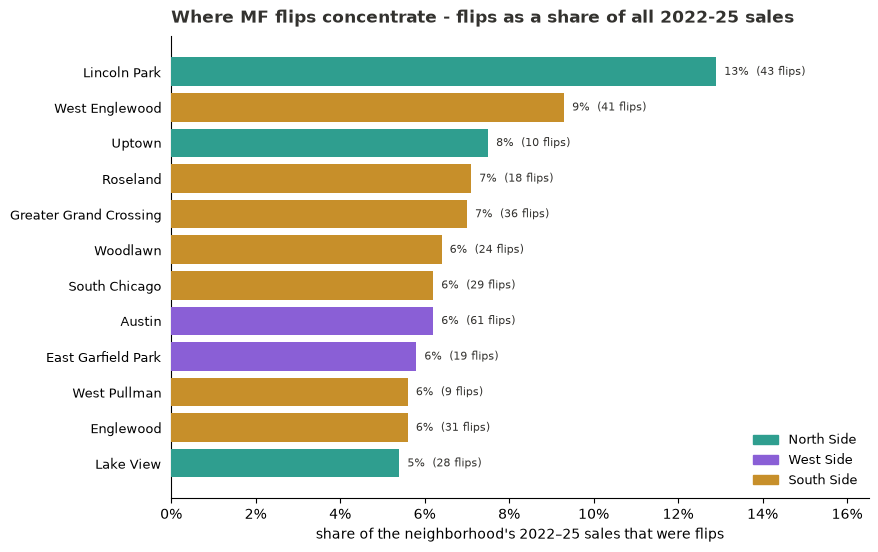

In [19]:
flip_geo = sd.flip_geography(enriched, flip_pairs, min_sales=100, n=12)
charts.plot_flip_share(
    flip_geo, n=12,
    title="Where MF flips concentrate - flips as a share of all 2022-25 sales")
plt.show()

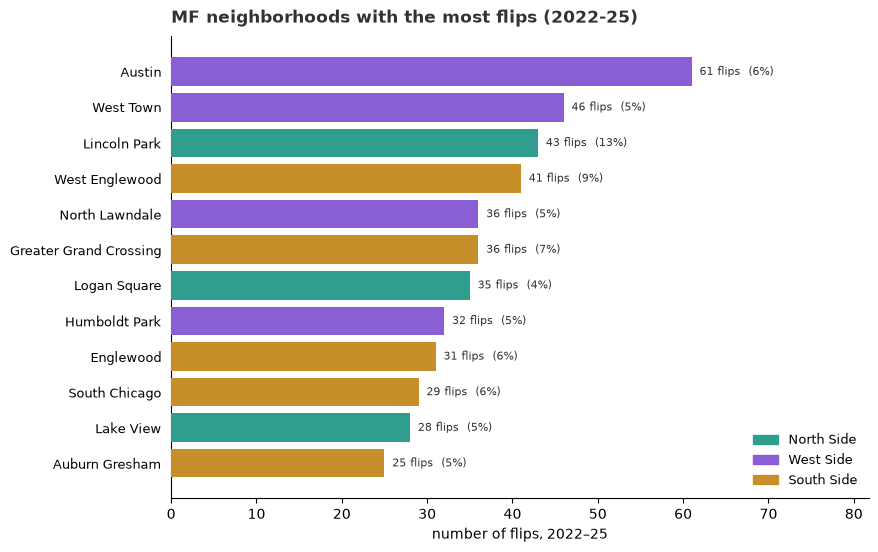

In [20]:
flip_count = sd.flip_geography(enriched, flip_pairs, min_sales=0, n=12, sort_by='flips')
charts.plot_flip_share(
    flip_count, n=12, value='flips', title="MF neighborhoods with the most flips (2022-25)")
plt.show()

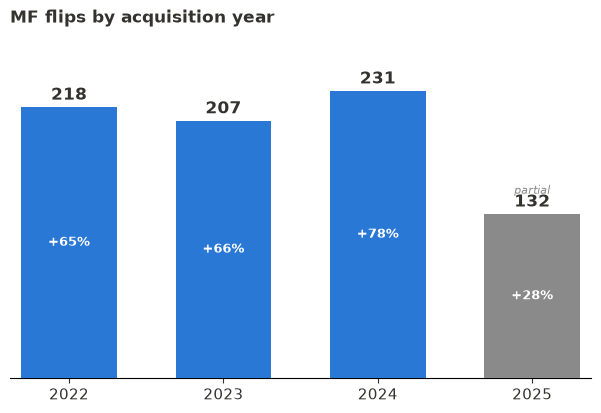

In [21]:
fy = sd.flips_by_year(flip_pairs, by='buy')
charts.plot_flips_by_year(fy, partial_years=(2025,), title="MF flips by acquisition year")
plt.show()

---
## Q8 - How fast, and how much does a two-flat flip pay?

**The median flip bought at $200k and resold for $395k - a +60% uplift - in about five
months** (154 days). Bigger than a condo flip (+34%), smaller than a house (+92%). The
cheapest South/West blocks post the biggest multiples - **West Englewood +161%, Englewood
+138%** - and the most extreme was **3633 N Paulina in Lake View: $30k -> $810k** (+2,600%).
Like the other markets, **79% of flips exit to a homeowner**, not another investor.

> **The honesty line: gross resale uplift, not profit** - these are distressed buildings
> bought cheap and renovated; the figure doesn't net out the rehab, carrying, or fees.

In [22]:
print(f"median MF flip:  buy ${flip_pairs['buy_price'].median():,.0f}  ->  resale "
      f"${flip_pairs['sell_price'].median():,.0f}   "
      f"(+{flip_pairs['gross_return'].median()*100:.0f}%, "
      f"{flip_pairs['hold_days'].median():.0f} days)")
for d in (90, 180, 270, 365):
    print(f"  flipped within {d:>3} days: {int((flip_pairs['hold_days'] <= d).sum()):,}")

median MF flip:  buy $200,000  ->  resale $395,000   (+60%, 154 days)
  flipped within  90 days: 293
  flipped within 180 days: 446
  flipped within 270 days: 634
  flipped within 365 days: 788


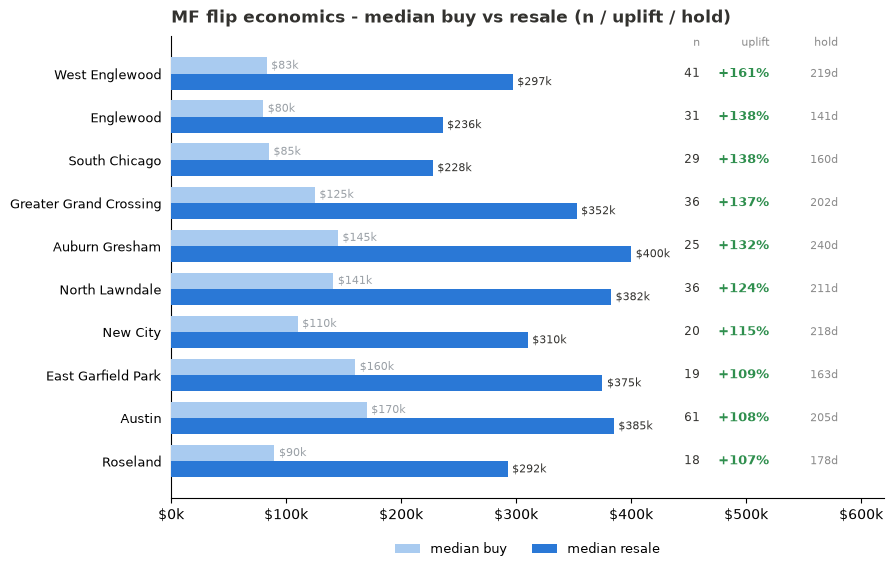

In [23]:
fr = sd.flip_returns_by_neighborhood(flip_pairs, enriched, min_flips=15, n=10)
charts.plot_flip_buysell(
    fr, n=10, title="MF flip economics - median buy vs resale (n / uplift / hold)")
plt.show()

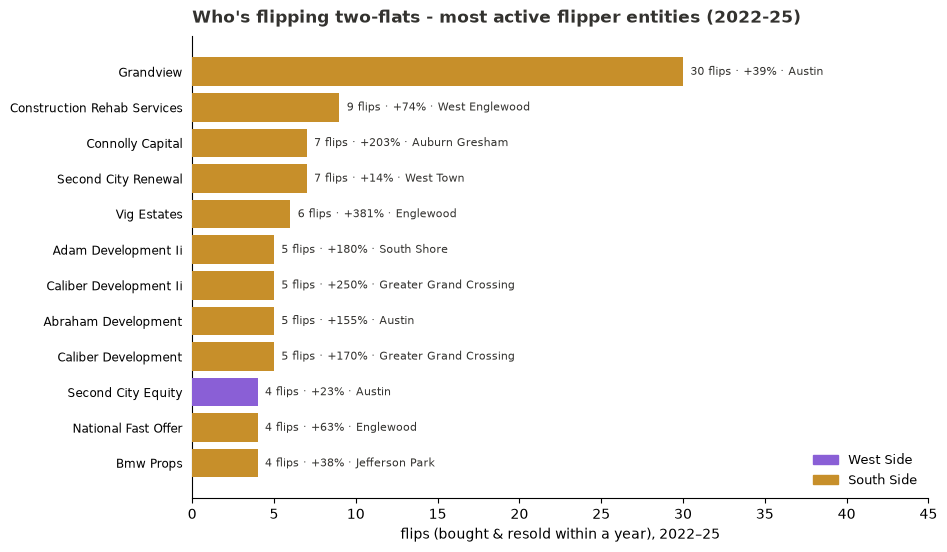

In [24]:
top_flip = sd.top_flippers(flip_pairs, n=12)
charts.plot_flipper_leaderboard(
    top_flip, n=12, title="Who's flipping two-flats - most active flipper entities (2022-25)")
plt.show()

In [25]:
from IPython.display import display
big = (flip_pairs[(flip_pairs['hold_days'] >= 90) & (flip_pairs['buy_price'] >= 25000)]
       .nlargest(10, 'gross_return')
       .assign(**{'return_%': lambda d: (d['gross_return'] * 100).round(0).astype(int),
                  'bought_by': lambda d: sd.normalize_entity_name(d['buyer_name']),
                  'sold_by': lambda d: sd.normalize_entity_name(d['seller_name']),
                  'sold_to': lambda d: sd.normalize_entity_name(d['sold_to_name']).fillna('?')
                             + d['sold_to_entity'].map({True: ' (entity)', False: ' (retail)'}).fillna('')}))
display(big[['address', K.REPORT_GEO, 'buy_price', 'sell_price', 'hold_days',
             'return_%', 'bought_by', 'sold_by', 'sold_to']]
        .style.hide(axis='index').format({'buy_price': '${:,.0f}', 'sell_price': '${:,.0f}'}))

address,loc_chicago_community_area_name,buy_price,sell_price,hold_days,return_%,bought_by,sold_by,sold_to
3633 N PAULINA ST,LAKE VIEW,"$30,000","$810,000",92,2600,TIMOTHY ENGLER,ANGELA YOUNGLOVE,BRETT BODDY (retail)
5803 S BISHOP ST 1,WEST ENGLEWOOD,"$35,000","$425,000",301,1114,JOESKI CONSTRUCTION,JOESKI CONSTRUCTION,MIGUEL ORTIZ (retail)
5743 S MORGAN ST 2ND,ENGLEWOOD,"$45,000","$350,000",136,678,JOSE NEGRETE,JOSE NEGRETE,ARTHUR E WADDELL JR (retail)
6225 S BISHOP ST 2,WEST ENGLEWOOD,"$45,000","$350,000",278,678,OSCAR RENTERIA,OSCAR RENTERIA,DARRYL P MITCHELL JR (retail)
69 E 100TH PL,ROSELAND,"$43,000","$298,000",231,593,ABRAHAM DEVELOPMENT,ABRAHAM DEVELOPMENT,JARON GREEN (retail)
1436 W 49TH PL,NEW CITY,"$45,000","$305,000",235,578,ROSALIO FLORES,PLANA HOMES,HIPOLITO ARROYO TREJO (retail)
6531 S PEORIA ST 1ST,ENGLEWOOD,"$55,000","$360,000",202,555,GOODLIFE,GOODLIFE,NIYA A ELFREEZE (retail)
8119 S MUSKEGON AVE,SOUTH CHICAGO,"$47,000","$303,000",260,545,INVESTMENTS MORA,INVESTMENTS MORA,JOSUE CAMPOS (retail)
5519 S PAULINA ST,WEST ENGLEWOOD,"$65,000","$405,000",180,523,SEEM GROUP,SEEM GROUP,WILLIAM SARGENT JR (retail)
10820 S STATE ST,ROSELAND,"$51,000","$307,000",214,502,ZBIGNIEW STRZEP,ZBIGNIEW STRZEP,RACHEL L GIBBS (retail)
